# Classifier comparison

Compares three approaches to categorising a NovaCart support ticket, on both
the **triage** stage (first message only) and the **final** stage (full
conversation thread):

1. **TF-IDF + Logistic Regression** — the standard scikit-learn baseline.
2. **Embeddings + nearest centroid** — `sentence-transformers` embeddings,
   no training on tickets at all. A category's "vector" is just the
   embedding of its taxonomy description + example phrases.
3. **Embeddings + Logistic Regression** — a trained classifier on top of the
   same embeddings.

Then a dedicated test: introduce one brand-new category partway through the
dataset with zero prior training examples, and see how each approach copes
with it from the very first ticket.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
from sklearn.model_selection import train_test_split

from taxonomy import load_taxonomy, Category
from data_generation import generate_dataset
from text_features import triage_text, final_text
from classifiers import TfidfBaseline, EmbeddingEncoder, EmbeddingCentroid, EmbeddingClassifier
from evaluation import score, results_table, plot_confusion_matrix, new_category_accuracy

pd.set_option("display.max_colwidth", 120)

In [2]:
taxonomy = load_taxonomy()
tickets_df, conversations_df = generate_dataset(n_tickets=1200, taxonomy=taxonomy, seed=42)

X_triage = triage_text(tickets_df)
y_triage = tickets_df["true_category_id_triage"]
X_final = final_text(tickets_df, conversations_df)
y_final = tickets_df["true_category_id_final"]

train_idx, test_idx = train_test_split(
    tickets_df.index, test_size=0.25, random_state=42, stratify=y_final
)
print(f"{len(train_idx)} train / {len(test_idx)} test tickets")

900 train / 300 test tickets


### Persist the held-out test set

Saved as a file (not just recreated by seed) so Phase 4 can score Gemini on
the exact same rows as every classifier above, rather than a hopefully-identical
regeneration.

In [3]:
holdout_df = tickets_df.loc[test_idx, ["id", "subject", "description", "status"]].copy()
holdout_df["triage_text"] = X_triage[test_idx]
holdout_df["final_text"] = X_final[test_idx]
holdout_df["true_category_id_triage"] = y_triage[test_idx]
holdout_df["true_category_id_final"] = y_final[test_idx]
holdout_df.to_csv("../outputs/eval_holdout_set.csv", index=False)
print(f"Saved outputs/eval_holdout_set.csv ({len(holdout_df)} rows)")

Saved outputs/eval_holdout_set.csv (300 rows)


## Fit all three classifiers

Each is trained once on the **final-stage** text (full conversation) since
that's the authoritative signal, then evaluated on both stages to see how
much accuracy triage gives up by only seeing the first message.

In [4]:
encoder = EmbeddingEncoder()  # loads all-MiniLM-L6-v2 once, shared by both embedding approaches

models = {
    "tfidf_logreg": TfidfBaseline("logreg"),
    "embedding_centroid": EmbeddingCentroid(encoder, taxonomy),
    "embedding_logreg": EmbeddingClassifier(encoder),
}

for name, model in models.items():
    model.fit(list(X_final[train_idx]), list(y_final[train_idx]))
print("Fitted:", list(models.keys()))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Fitted: ['tfidf_logreg', 'embedding_centroid', 'embedding_logreg']


In [5]:
from classifier_router import HybridRouter

# The router wraps the already-fitted TF-IDF classifier and the
# already-built centroid classifier — no extra fitting needed.
models["hybrid_router"] = HybridRouter(models["tfidf_logreg"], models["embedding_centroid"])
print("Added hybrid_router: TF-IDF+LogReg for known categories, centroid fallback for anything it's never seen")

Added hybrid_router: TF-IDF+LogReg for known categories, centroid fallback for anything it's never seen


## Final-stage results (full conversation, authoritative)

In [6]:
final_results = {}
final_preds = {}
for name, model in models.items():
    pred = model.predict(list(X_final[test_idx]))
    final_preds[name] = pred
    final_results[name] = score(list(y_final[test_idx]), pred)

results_table(final_results)

,accuracy,macro_f1
tfidf_logreg,0.926667,0.918521
hybrid_router,0.926667,0.918521
embedding_logreg,0.876667,0.852862
embedding_centroid,0.823333,0.744758


## Triage-stage results (first message only)

Note: triage ground truth is `true_category_id_triage` — what the opening
message alone implies — which differs from the final label on drift cases.

In [7]:
triage_results = {}
for name, model in models.items():
    pred = model.predict(list(X_triage[test_idx]))
    triage_results[name] = score(list(y_triage[test_idx]), pred)

results_table(triage_results)

,accuracy,macro_f1
tfidf_logreg,0.986667,0.989685
hybrid_router,0.986667,0.989685
embedding_logreg,0.986667,0.988049
embedding_centroid,0.940000,0.897868


## Confusion matrix — best final-stage model

Shows which categories the strongest model still mixes up — typically the
confusable pairs the dataset generator deliberately blends in ambiguous
cases (e.g. refund status vs. duplicate charge, defective vs. wrong item).

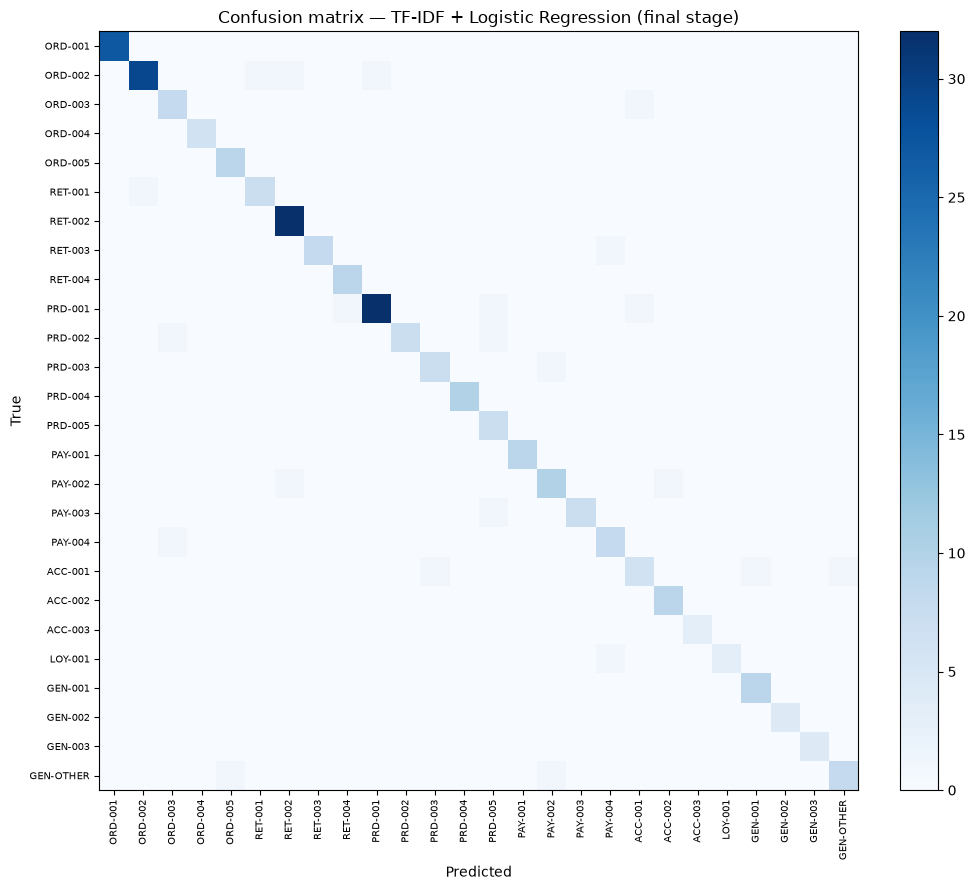

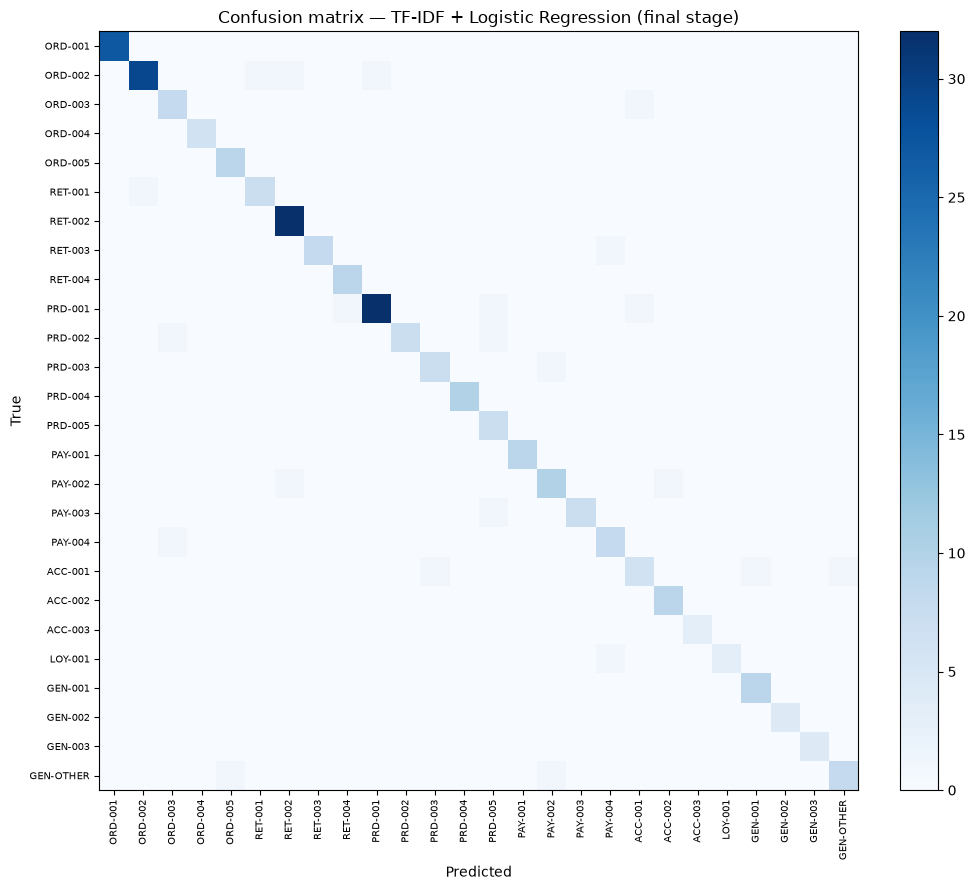

In [8]:
best_model_name = results_table(final_results).index[0]
labels = taxonomy.active_ids()
fig, cm = plot_confusion_matrix(
    list(y_final[test_idx]), final_preds[best_model_name], labels,
    title=f"Confusion matrix — {models[best_model_name].name} (final stage)",
)
fig.savefig("../outputs/confusion_matrix_final.png", dpi=150, bbox_inches="tight")
fig

## New-category test

Simulate the support team introducing a brand-new category ("Express
shipping request") partway through the ticket stream, with **zero** training
examples available at classifier build time. All three classifiers are
built/trained only on tickets *before* the injection point — mirroring a
real deployment where the new category didn't exist yet when the model was
last trained — then evaluated on tickets from the very first occurrence
onward.

In [9]:
new_category = Category(
    category_id="SHIP-EXP",
    name="Express shipping request",
    group="Order & shipping",
    description="Customer asks to upgrade their order to express/expedited shipping.",
    example_phrases=[
        "can I get this shipped faster?",
        "is express shipping available for my order?",
    ],
    status="active", created_at="2025-07-01", deprecated_at=None, replaced_by=None, taxonomy_version=2,
)

nc_tickets_df, nc_conversations_df = generate_dataset(
    n_tickets=800, taxonomy=taxonomy, seed=7,
    new_category_injection={"category": new_category, "start_index": 400, "rate": 0.15},
)
nc_X_final = final_text(nc_tickets_df, nc_conversations_df)
nc_y_final = nc_tickets_df["true_category_id_final"]

# Classifiers are only exposed to tickets *before* the new category existed.
pretrain_mask = nc_tickets_df.index < 400

nc_tfidf = TfidfBaseline("logreg").fit(list(nc_X_final[pretrain_mask]), list(nc_y_final[pretrain_mask]))
nc_embclf = EmbeddingClassifier(encoder).fit(list(nc_X_final[pretrain_mask]), list(nc_y_final[pretrain_mask]))

# The centroid approach only needs the taxonomy updated — no retraining.
nc_centroid = EmbeddingCentroid(encoder, taxonomy)
nc_centroid.add_category(new_category)

nc_predictions = {
    "tfidf_logreg": nc_tfidf.predict(list(nc_X_final)),
    "embedding_logreg": nc_embclf.predict(list(nc_X_final)),
    "embedding_centroid": nc_centroid.predict(list(nc_X_final)),
}


### Persist the new-category dataset

Same reasoning as the held-out set: Phase 4 scores Gemini on this exact file,
not a re-derived seed=7 dataset.

In [10]:
nc_export_df = nc_tickets_df[["id", "subject", "description", "status", "is_injected_new_category"]].copy()
nc_export_df["triage_text"] = triage_text(nc_tickets_df)
nc_export_df["final_text"] = nc_X_final
nc_export_df["true_category_id_final"] = nc_y_final
nc_export_df.to_csv("../outputs/eval_new_category_set.csv", index=False)
print(f"Saved outputs/eval_new_category_set.csv ({len(nc_export_df)} rows, {nc_export_df['is_injected_new_category'].sum()} new-category)")

Saved outputs/eval_new_category_set.csv (800 rows, 52 new-category)


### Router: new-category coverage with no degradation elsewhere

The router routes purely on whether the centroid's prediction is a category
the trained classifier has never seen — never on confidence, since the
trained model's argmax can't surface an unseen class regardless of how
uncertain it is. Two things to check:

1. **New-category tickets** should route through the centroid path and hit
   the same ~100% accuracy as the standalone centroid classifier.
2. **Everything else** should route through the trained TF-IDF classifier
   and match its standalone final/triage accuracy *exactly* — the router
   should add coverage, not trade it off.

In [11]:
# Router: reuses the same pre-injection-trained TF-IDF classifier, paired
# with a centroid classifier that *does* know about the new category
# (mirrors how this would run in production: taxonomy.yaml gets the new
# entry immediately, the trained model catches up on its next retrain).
from classifier_router import HybridRouter

nc_router = HybridRouter(nc_tfidf, nc_centroid)
nc_predictions["hybrid_router"] = nc_router.predict(list(nc_X_final))

for name in ["tfidf_logreg", "embedding_logreg", "embedding_centroid", "hybrid_router"]:
    pred = nc_predictions[name]
    result = new_category_accuracy(nc_tickets_df, pred, "SHIP-EXP")
    print(f"{name}: accuracy on new category = {result['accuracy']:.0%} ({result['correct']}/{result['n_new_category_tickets']})")

tfidf_logreg: accuracy on new category = 0% (0/52)
embedding_logreg: accuracy on new category = 0% (0/52)
embedding_centroid: accuracy on new category = 100% (52/52)
hybrid_router: accuracy on new category = 100% (52/52)


**Takeaway:** the trained classifiers (TF-IDF and embeddings + Logistic
Regression) have never seen the new category and score 0% on it — they
confidently misfile it into whichever existing category looks closest,
which is the real risk of shipping a trained classifier without a retrain
cycle. The nearest-centroid approach recognises the new category correctly
from the very first ticket, because all it needed was the new taxonomy
entry (description + example phrases) — no retraining step at all.

### Recommendation: use the hybrid router for production

Of the four approaches compared here, the **hybrid router** is what this
project would actually deploy: the trained TF-IDF classifier's accuracy on
every category the support team has already seen, plus the centroid
classifier's ability to categorise a brand-new type of contact correctly
from ticket one — as soon as someone adds it to `taxonomy.yaml`, with no
retraining step in between.

**Not built here, intentionally:** the process that periodically
"graduates" a centroid-only category into the trained classifier once it
has accumulated enough real examples (i.e. scheduled retraining). That
stays a documented follow-up rather than code in this repo — the natural
place to hang it is the weekly Cloud Scheduler job introduced in Phase 4,
which could retrain and redeploy the TF-IDF/embedding classifier on a
rolling basis. See the README's "Cost-aware model selection" reflection.

## Save summary metrics for the README / dashboard

In [12]:
summary = results_table(final_results).rename(columns={"accuracy": "final_accuracy", "macro_f1": "final_macro_f1"})
summary["triage_accuracy"] = pd.Series({k: v["accuracy"] for k, v in triage_results.items()})
summary["triage_macro_f1"] = pd.Series({k: v["macro_f1"] for k, v in triage_results.items()})
summary.to_csv("../outputs/classifier_comparison_summary.csv")
summary

,final_accuracy,final_macro_f1,triage_accuracy,triage_macro_f1
tfidf_logreg,0.926667,0.918521,0.986667,0.989685
hybrid_router,0.926667,0.918521,0.986667,0.989685
embedding_logreg,0.876667,0.852862,0.986667,0.988049
embedding_centroid,0.823333,0.744758,0.940000,0.897868
